<a href="https://colab.research.google.com/github/Olleum/-BI--Yandex-DataLens-/blob/main/Laba2%D0%93%D0%A0%D0%90%D0%A4%D0%98%D0%9A.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
matrix = []
n = int(input("Введите n: "))

for i in range(n):
    matrix.append([])
    print(f"Введите элементы для строки {i+1}:")
    for j in range(n + 1):
        element = float(input())
        matrix[i].append(element)


Введите n: 4
Введите элементы для строки 1:
24
2
4
-9
-9
Введите элементы для строки 2:
-6
-27
-8
-6
-76
Введите элементы для строки 3:
-4
8
19
6
-79
Введите элементы для строки 4:
4
5
-3
-13
-70


In [5]:
A = []
b = []

for i in range(n):
    A.append(matrix[i][:n])  # первые n элементов
    b.append(matrix[i][n])  # последний элемент

import numpy as np
A = np.array(A)
b = np.array(b)

print("Матрица A:")
print(A)

print("Вектор b:")
print(b)

Матрица A:
[[ 24.   2.   4.  -9.]
 [ -6. -27.  -8.  -6.]
 [ -4.   8.  19.   6.]
 [  4.   5.  -3. -13.]]
Вектор b:
[ -9. -76. -79. -70.]


In [16]:
eps = float(input("Введите точность (например 0.001): "))

x = np.zeros(n)
k = 0

while True:
    x_new = np.zeros(n)

    for i in range(n):
        s = 0
        for j in range(n):
            if j != i:
                s += A[i][j] * x[j]

        x_new[i] = (b[i] - s) / A[i][i]

    if np.max(np.abs(x_new - x)) < eps:
        break

    x = x_new.copy()
    k += 1

print("\nРешение (простая итерация):")
for i in range(n):
    print(f"x{i+1} = {round(x_new[i], 5)}")

print("Количество итераций:", k)

Введите точность (например 0.001): 0.1

Решение (простая итерация):
x1 = 4.05961
x2 = 1.97693
x3 = -7.01681
x4 = 9.04231
Количество итераций: 6


In [13]:
x = np.zeros(n)
k = 0

while True:
    x_new = x.copy()

    for i in range(n):
        s1 = 0
        s2 = 0

        for j in range(i):
            s1 += A[i][j] * x_new[j]

        for j in range(i + 1, n):
            s2 += A[i][j] * x[j]

        x_new[i] = (b[i] - s1 - s2) / A[i][i]

    if np.max(np.abs(x_new - x)) < eps:
        break

    x = x_new.copy()
    k += 1

print("\nРешение (Зейдель):")
for i in range(n):
    print(f"x{i+1} = {round(x_new[i], 5)}")

print("Количество итераций:", k)


Решение (Зейдель):
x1 = 4.0
x2 = 2.0
x3 = -7.0
x4 = 9.0
Количество итераций: 10


In [17]:
print("\nПРОВЕРКА:")

for i in range(n):
    left = 0

    for j in range(n):
        left += A[i][j] * x_new[j]

    print(f"Уравнение {i+1}: {round(left,4)} = {b[i]}")


ПРОВЕРКА:
Уравнение 1: -8.0636 = -9.0
Уравнение 2: -75.854 = -76.0
Уравнение 3: -79.4886 = -79.0
Уравнение 4: -70.3765 = -70.0


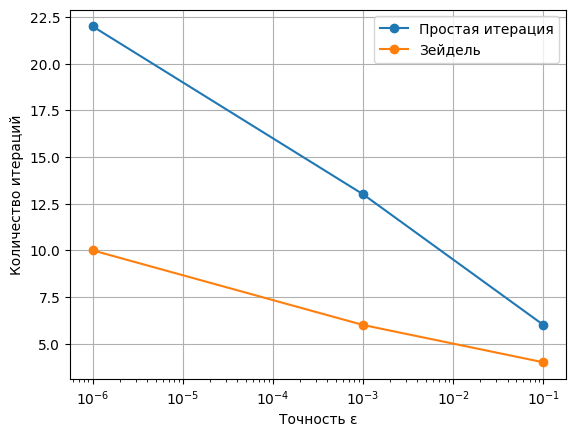

In [19]:
import numpy as np
import matplotlib.pyplot as plt

eps_values = [0.1, 0.001, 0.000001]

iter_simple = []
iter_zeidel = []

for eps in eps_values:

    #Итерация
    x = np.zeros(n)
    k = 0

    while True:
        x_new = np.zeros(n)

        for i in range(n):
            s = 0
            for j in range(n):
                if j != i:
                    s += A[i][j] * x[j]

            x_new[i] = (b[i] - s) / A[i][i]

        if np.max(np.abs(x_new - x)) < eps:
            break

        x = x_new.copy()
        k += 1

    iter_simple.append(k)

    #Зейдель
    x = np.zeros(n)
    k = 0

    while True:
        x_new = x.copy()

        for i in range(n):
            s1 = 0
            s2 = 0

            for j in range(i):
                s1 += A[i][j] * x_new[j]

            for j in range(i + 1, n):
                s2 += A[i][j] * x[j]

            x_new[i] = (b[i] - s1 - s2) / A[i][i]

        if np.max(np.abs(x_new - x)) < eps:
            break

        x = x_new.copy()
        k += 1

    iter_zeidel.append(k)

#ГРафик
plt.figure()
plt.plot(eps_values, iter_simple, marker='o', label='Простая итерация')
plt.plot(eps_values, iter_zeidel, marker='o', label='Зейдель')

plt.xscale('log')  #лог. шкала
plt.xlabel("Точность ε")
plt.ylabel("Количество итераций")
plt.legend()
plt.grid()

plt.show()